# Estimating International Roughness Index (IRI) using Dual-Branch 1D-CNN and Contextual Features
**Author:** [Nishkarsh]
**Date:** [15 june 2026]

## 1. Environment Setup and Global Configuration

All third-party dependencies are imported here, followed by the declaration of global constants that govern the entire pipeline. Path constants (`BASE_DATA_DIR`, `OUTPUT_DIR`) must be updated to reflect the local filesystem prior to execution. Spatial windowing is controlled by `WINDOW_SIZE_M` (100 m) and `STEP_SIZE_M` (10 m), yielding an effective overlap of 90% between consecutive windows. The constant `FINAL_SPATIAL_STEPS` (400 points over 100 m) fixes the spatial resolution at 0.25 m per step, ensuring that the raw IMU branch receives a tensor of consistent shape regardless of the vehicle's instantaneous velocity. Data augmentation during preprocessing is governed by `AUGMENT_HZ`, which enumerates the simulated sensor sampling rates applied per window.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, 
                                     GlobalAveragePooling1D, GlobalMaxPooling1D, 
                                     Dense, Concatenate, Dropout, 
                                     BatchNormalization, DepthwiseConv1D)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ==========================================
# Configuration and Hyperparameters
# ==========================================

# Paths (Ensure these directories exist or update them accordingly)
BASE_DATA_DIR = r"D:\Coding\Hackathon\GFG\ARM\ARM\ml_model_work\data\simulation\data\IRI_new_experiments"
OUTPUT_DIR = r"D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_v2\output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Spatial Windowing Constants
WINDOW_SIZE_M = 100.0
STEP_SIZE_M = 10.0
FINAL_SPATIAL_STEPS = 400  # Resolution: 0.25m per step

# Filtering Constants
MIN_SPEED_MS = 1.0  # Threshold to drop near-stationary data

# Data Augmentation (Simulated Sampling Rates)
AUGMENT_HZ = [10, 15, 20, 25, 30, 50]


# Sensor Features
RAW_FEATURES = ['ax', 'ay', 'az', 'wx', 'wy', 'wz']

# Train/Validation/Test Splits by Simulated Route
SPLITS = {
    'train': ['east_coast_usa', 'west_coast_usa'],
    'val': ['automation_test_track_trip_1'],
    'test': ['automation_test_track_trip_2', 'automation_test_track_trip_3']
}

print(f"[*] Configuration loaded. Output directory: {OUTPUT_DIR}")

[*] Configuration loaded. Output directory: D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_v2\output


## 2. Spatial Domain Resampling and Feature Extraction

Raw vehicle telemetry is collected in the time domain, whose sample density is directly proportional to vehicle speed. A road segment traversed at 60 km/h yields fewer time-domain samples than the same segment traversed at 20 km/h, introducing a speed-dependent bias into any model trained on temporal sequences. To eliminate this confound, all signals are resampled from the time domain into the spatial domain via cumulative odometry integration, producing a fixed-length representation of every 100 m window regardless of travel speed.

The function `extract_context_features` computes 13 handcrafted statistical descriptors from the spatially resampled IMU window. These include RMS acceleration along all relevant axes, the crest factor and peak-to-peak amplitude of vertical acceleration (`az`), the mean crossing rate, rotational RMS values, and two pseudo-spectral energy ratios. The spectral ratios are obtained by converting spatial-domain FFT frequencies to temporal frequencies using mean window speed, then integrating power spectral density within the body-bounce band (1–4 Hz) and the tire-hop band (4–15 Hz).

The function `process_trip_data` applies a minimum speed filter (`MIN_SPEED_MS`), constructs cumulative distance via Euler integration of the speed signal, and applies a sliding spatial window with 90% overlap. Within each window, temporal jitter augmentation is performed by re-sampling the signal at a randomly selected frequency drawn from `AUGMENT_HZ`, simulating heterogeneous sensor hardware. Each IMU channel is then mapped onto a fixed 400-point spatial grid using edge-padded linear interpolation. Following spatial resampling, a physics-informed speed normalization is applied to the vertical acceleration channel (`az`): the signal is scaled by the squared ratio of a reference speed (80 km/h = 22.22 m/s) to the instantaneous speed, correcting for the known quadratic relationship between vehicle velocity and vertical acceleration magnitude on a surface of fixed roughness.

The function `build_datasets` orchestrates parallel processing of all trips via `joblib`, assigns each trip to the appropriate partition as defined in `SPLITS`, and serializes the resulting arrays to a compressed `.npz` archive.

In [2]:
# ==========================================
# Feature Extraction and Spatial Resampling
# ==========================================

def extract_context_features(raw_data_window, speed_array, distance_m):
    """
    Extracts 13 contextual features from the spatially resampled window.
    
    Parameters:
        raw_data_window (np.ndarray): Shape (400, 6) -> [ax, ay, az, wx, wy, wz]
        speed_array (np.ndarray): Spatially interpolated speed values.
        distance_m (float): Starting distance of the window.
        
    Returns:
        np.ndarray: Array of 13 statistical and pseudo-spectral features.
    """
    ax, ay, az, wx, wy, wz = [raw_data_window[:, i] for i in range(6)]
    N = len(az)
    
    speed_mean = np.mean(speed_array)
    speed_std = np.std(speed_array)
    
    rms_az = np.sqrt(np.mean(az**2))
    rms_ay = np.sqrt(np.mean(ay**2))
    var_az = np.var(az)
    crest_factor_az = np.max(np.abs(az)) / (rms_az + 1e-6)
    
    zero_crossings_az = len(np.where(np.diff(np.sign(az)))[0])
    mcr_az = zero_crossings_az / N
    p2p_az = np.max(az) - np.min(az)
    
    rms_wz = np.sqrt(np.mean(wz**2))
    rms_wy = np.sqrt(np.mean(wy**2))
    mean_abs_ax = np.mean(np.abs(ax))
    
    # Pseudo-Spectral features (converting spatial frequencies to temporal)
    fft_vals = np.fft.rfft(az)
    psd = np.abs(fft_vals)**2
    freqs_spatial = np.fft.rfftfreq(N, d=0.25)
    
    if speed_mean > 0:
        freqs_temporal = freqs_spatial * speed_mean
        band_1_4 = np.sum(psd[(freqs_temporal >= 1.0) & (freqs_temporal <= 4.0)])
        band_4_15 = np.sum(psd[(freqs_temporal > 4.0) & (freqs_temporal <= 15.0)])
        total_energy = np.sum(psd) + 1e-6
        
        energy_ratio_1_4 = band_1_4 / total_energy
        energy_ratio_4_15 = band_4_15 / total_energy
    else:
        energy_ratio_1_4, energy_ratio_4_15 = 0.0, 0.0

    return np.array([
        speed_mean, speed_std, rms_az, rms_ay, var_az, crest_factor_az,
        mcr_az, p2p_az, rms_wz, rms_wy, mean_abs_ax, 
        energy_ratio_1_4, energy_ratio_4_15
    ])

def process_trip_data(df, trip_identifier):
    """Parses trip telemetry, filters slow speeds, and applies spatial windowing."""
    X_raw_list, X_ctx_list, y_list = [], [], []
    
    df = df[df['speed_ms'] >= MIN_SPEED_MS].copy().sort_values('sample_number')
    if len(df) < 50:
        return [], [], []
        
    df['time_s'] = df['sample_number'] * 0.01 
    df['dt'] = df['time_s'].diff().fillna(0.01)
    df['dx'] = df['speed_ms'] * df['dt']
    df['cumulative_distance'] = df['dx'].cumsum()
    
    max_dist = df['cumulative_distance'].max()
    
    for start_dist in np.arange(0, max_dist - WINDOW_SIZE_M, STEP_SIZE_M):
        end_dist = start_dist + WINDOW_SIZE_M
        patch = df[(df['cumulative_distance'] >= start_dist) & (df['cumulative_distance'] < end_dist)]
        
        if len(patch) < 20: continue 
        
        target_iri = patch['IRI'].mean()
        start_time, end_time = patch['time_s'].min(), patch['time_s'].max()
        
        # Temporal jitter and augmentation
        target_hz = np.random.choice(AUGMENT_HZ)
        poll_interval = 1.0 / target_hz
        t_polls = np.arange(start_time, end_time, poll_interval)
        if len(t_polls) < 5: continue
        t_polls += np.random.uniform(0, poll_interval * 0.2, size=len(t_polls)) 
        
        augmentedd_features = []
        for feat in RAW_FEATURES:
            os_sensor = interp1d(patch['time_s'], patch[feat], kind='previous', fill_value="extrapolate")
            augmentedd_features.append(os_sensor(t_polls))
            
        os_speed = interp1d(patch['time_s'], patch['speed_ms'], kind='linear', fill_value="extrapolate")
        augmentedd_speed = os_speed(t_polls)
        
        os_dist = interp1d(patch['time_s'], patch['cumulative_distance'], kind='linear', fill_value="extrapolate")
        augmentedd_dists = os_dist(t_polls)
        
        # Spatial Domain Resampling to fixed grid
        fixed_spatial_grid = np.linspace(start_dist, end_dist, FINAL_SPATIAL_STEPS)
        fixed_patch_features = []
        
        for i in range(len(RAW_FEATURES)):
            # FIX: Use edge-padding instead of linear extrapolation for oscillatory signals
            spatial_fix = interp1d(
                augmentedd_dists, 
                augmentedd_features[i], 
                kind='linear', 
                bounds_error=False, 
                fill_value=(augmentedd_features[i][0], augmentedd_features[i][-1])
            )
            fixed_patch_features.append(spatial_fix(fixed_spatial_grid))
            
        spatial_speed = interp1d(
            augmentedd_dists, 
            augmentedd_speed, 
            kind='linear', 
            bounds_error=False, 
            fill_value=(augmentedd_speed[0], augmentedd_speed[-1])
        )(fixed_spatial_grid)
            
        X_raw_filtered = np.column_stack(fixed_patch_features) 
        
        # Physics-informed Speed Normalization of Vertical Acceleration
        az_idx = RAW_FEATURES.index('az')
        v_safe = np.maximum(spatial_speed, 5.0) 
        X_raw_filtered[:, az_idx] = X_raw_filtered[:, az_idx] * ((22.22 / v_safe) ** 2)
        
        X_ctx = extract_context_features(X_raw_filtered, spatial_speed, start_dist)
        
        X_raw_list.append(X_raw_filtered)
        X_ctx_list.append(X_ctx)
        y_list.append(target_iri)
            
    return X_raw_list, X_ctx_list, y_list

def worker_process_trip(car, route, trip):
    """Joblib worker function to process individual trips."""
    trip_key = f"{route}_{trip}"
    
    split = 'train'
    if route in SPLITS['train']:
        split = 'train'
    elif route == 'automation_test_track':
        if trip == 'trip_1': split = 'val'
        elif trip in ['trip_2', 'trip_3']: split = 'test'
        else: return None
    else:
        return None
        
    csv_path = os.path.join(BASE_DATA_DIR, car, route, trip, 'readings_2.csv')
    if not os.path.exists(csv_path): return None
        
    df = pd.read_csv(csv_path)
    x_r, x_c, y_val = process_trip_data(df, trip_key)
    
    if len(y_val) == 0: return None
    return {'split': split, 'raw': x_r, 'ctx': x_c, 'y': y_val}

def build_datasets():
    """Compiles the dataset utilizing parallel processing across CPU cores."""
    datasets = {'train': {'raw': [], 'ctx': [], 'y': []},
                'val':   {'raw': [], 'ctx': [], 'y': []},
                'test':  {'raw': [], 'ctx': [], 'y': []}}
    
    tasks = []
    if os.path.exists(BASE_DATA_DIR):
        for car in sorted(os.listdir(BASE_DATA_DIR)):
            car_p = os.path.join(BASE_DATA_DIR, car)
            if not os.path.isdir(car_p) or car == 'desktop.ini': continue
            for route in sorted(os.listdir(car_p)):
                route_p = os.path.join(car_p, route)
                if not os.path.isdir(route_p) or route == 'desktop.ini': continue
                for trip in sorted(os.listdir(route_p)):
                    if os.path.isdir(os.path.join(route_p, trip)):
                        tasks.append((car, route, trip))
                
    print(f"[*] Dispatching {len(tasks)} trips to worker pool...")
    start_time = time.time()
    
    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(worker_process_trip)(car, route, trip) for car, route, trip in tasks
    )
    
    for res in results:
        if res:
            split = res['split']
            datasets[split]['raw'].extend(res['raw'])
            datasets[split]['ctx'].extend(res['ctx'])
            datasets[split]['y'].extend(res['y'])

    for split in ['train', 'val', 'test']:
        datasets[split]['raw'] = np.array(datasets[split]['raw'], dtype=np.float32)
        datasets[split]['ctx'] = np.array(datasets[split]['ctx'], dtype=np.float32)
        datasets[split]['y'] = np.array(datasets[split]['y'], dtype=np.float32)
        
        print(f"{split.upper()} SET -> Raw: {datasets[split]['raw'].shape}, Ctx: {datasets[split]['ctx'].shape}")
        
    print(f"[*] Processing completed in {time.time() - start_time:.2f}s")
    return datasets

# NOTE: datset generation functions are below

d = build_datasets()
data_path = os.path.join(OUTPUT_DIR, "iri_v2_data.npz")
np.savez_compressed(data_path, 
                    x_train_raw=d['train']['raw'], x_train_ctx=d['train']['ctx'], y_train=d['train']['y'],
                    x_val_raw=d['val']['raw'], x_val_ctx=d['val']['ctx'], y_val=d['val']['y'],
                    x_test_raw=d['test']['raw'], x_test_ctx=d['test']['ctx'], y_test=d['test']['y'])
print(f"[*] Dataset serialized to {data_path}")

[*] Dispatching 19 trips to worker pool...
TRAIN SET -> Raw: (9082, 400, 6), Ctx: (9082, 13)
VAL SET -> Raw: (2796, 400, 6), Ctx: (2796, 13)
TEST SET -> Raw: (1903, 400, 6), Ctx: (1903, 13)
[*] Processing completed in 11.04s
[*] Dataset serialized to D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_v2\output\iri_v2_data.npz


## 3. Model Architecture

The estimation model adopts a dual-input architecture that processes the two complementary feature representations in parallel before fusing them for final regression.

**Branch 1 — Spatial (Raw IMU):** The input tensor of shape (400, 6) is first processed by a channel-wise `DepthwiseConv1D` layer with a depth multiplier of 2, which learns per-channel spatial filters at a fraction of the parameter cost of a standard convolution. Two subsequent `Conv1D` layers with filter sizes of 48 and 64 progressively abstract spatial frequency patterns from the IMU signals. A dual-pooling head — combining `GlobalAveragePooling1D` and `GlobalMaxPooling1D` — is applied to the final feature map. The average pool captures the sustained roughness profile over the window, while the max pool is sensitive to acute impulse events such as potholes. A `Dropout` layer with rate 0.3 is applied to the concatenated pool output.

**Branch 2 — Contextual (Statistical Features):** The 13-dimensional context vector passes through a single `Dense(32)` layer with ReLU activation, followed by `BatchNormalization` and `Dropout(0.2)`.

**Fusion:** The outputs of both branches are concatenated and passed through two fully connected layers (64 and 32 units, respectively). The final regression output uses a `Softplus` activation, which enforces strict non-negativity — a physically motivated constraint, as the IRI is defined on [0, ∞).

The model is compiled with the `AsymmetricHuberLoss` function, which applies a configurable penalty multiplier (`penalty_ratio = 4.0`) to under-predictions. This asymmetry counteracts the compression effect of the `log1p` target transformation on high-IRI samples, ensuring that severe road conditions are not systematically underestimated.

In [3]:
# ==========================================
# Neural Network Architecture
# ==========================================

class AsymmetricHuberLoss(tf.keras.losses.Loss):
    """
    Penalizes under-predictions (True > Predicted) heavily to counteract 
    the compression effects of log1p target transformation on severe roads.
    """
    def __init__(self, delta=2.0, penalty_ratio=4.0, **kwargs):
        # **kwargs catches 'reduction' and 'name' passed by Keras during loading
        super().__init__(**kwargs)
        self.delta = delta
        self.penalty_ratio = penalty_ratio
        
    def call(self, y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)
        
        # Standard Huber calculation
        quadratic = tf.minimum(abs_error, self.delta)
        linear = abs_error - quadratic
        huber_base = 0.5 * tf.square(quadratic) + self.delta * linear
        
        # Apply asymmetric weighting
        is_underpredicting = tf.cast(error > 0, tf.float32)
        weights = is_underpredicting * self.penalty_ratio + (1.0 - is_underpredicting) * 1.0
        
        return tf.reduce_mean(weights * huber_base)

    def get_config(self):
        # This tells Keras how to save/load the custom parameters to disk
        config = super().get_config()
        config.update({
            "delta": self.delta,
            "penalty_ratio": self.penalty_ratio,
        })
        return config


def build_iri_model():
    """
    Constructs a dual-input 1D-CNN + Dense network optimized for mobile/edge deployment.
    """
    # --- Branch 1: Spatial Feature Extraction (Raw IMU) ---
    input_raw = Input(shape=(FINAL_SPATIAL_STEPS, 6), name="raw_imu")
    
    # Efficient spatial filtering block
    x = DepthwiseConv1D(kernel_size=5, depth_multiplier=2, activation='relu', padding='same')(input_raw)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    x = Conv1D(filters=48, kernel_size=5, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    
    # Dual-pooling captures both sustained roughness and acute impacts
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    cnn_features = Concatenate(name="cnn_features")([avg_pool, max_pool])
    cnn_features = Dropout(0.3)(cnn_features) 
    
    # --- Branch 2: Contextual Network (Extracted Statistics) ---
    input_ctx = Input(shape=(13,), name="context_stats")
    
    y = Dense(32, activation='relu')(input_ctx)
    y = BatchNormalization()(y)
    y = Dropout(0.2)(y)
    
    # --- Feature Fusion ---
    merged = Concatenate(name="fusion_layer")([cnn_features, y])
    
    z = Dense(64, activation='relu')(merged)
    z = Dropout(0.2)(z)
    z = Dense(32, activation='relu')(z)
    
    # Softplus guarantees positive IRI
    output_iri = Dense(1, activation='softplus', name="predicted_iri")(z)
    
    model = Model(inputs=[input_raw, input_ctx], outputs=output_iri)
    
    # FIX: Replaced standard Huber with Asymmetric Huber
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=AsymmetricHuberLoss(delta=2.0, penalty_ratio=4.0), 
                  metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')])
    
    return model

# Display the topology
model_instance = build_iri_model()
model_instance.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 raw_imu (InputLayer)           [(None, 400, 6)]     0           []                               
                                                                                                  
 depthwise_conv1d (DepthwiseCon  (None, 400, 12)     72          ['raw_imu[0][0]']                
 v1D)                                                                                             
                                                                                                  
 batch_normalization (BatchNorm  (None, 400, 12)     48          ['depthwise_conv1d[0][0]']       
 alization)                                                                                       
                                                                                              

## 4. Model Training, Class Imbalance Mitigation, and TFLite Export

**Target Transformation:** The IRI target variable is transformed via `log1p` prior to training. This compresses the long right tail of the IRI distribution (which extends to values exceeding 20 m/km for severely degraded surfaces), stabilizing gradient magnitudes and improving convergence on the dominant low-IRI regime without discarding high-IRI samples.

**Class Imbalance Mitigation:** Two complementary strategies are applied. First, all samples whose IRI exceeds 10.0 m/km are duplicated via random oversampling, increasing their representation in each mini-batch. Second, a 2D Inverse Frequency Sample Weighting scheme (`compute_2d_sample_weights`) assigns per-sample weights based on the joint (speed, IRI) bin histogram. Cells that are densely populated in the speed-IRI space receive low weights, while sparsely populated cells (e.g., high-IRI windows at highway speeds) receive amplified weights. This decouples the model's loss landscape from the empirical marginal distribution of speed, preventing the network from learning spurious correlations between velocity and roughness.

**Training Protocol:** The model is trained for a maximum of 150 epochs with a batch size of 64. Three Keras callbacks govern convergence: `EarlyStopping` with a patience of 15 epochs (restoring the best weights upon termination), `ReduceLROnPlateau` with a reduction factor of 0.5 and a patience of 5 epochs, and `ModelCheckpoint` which preserves the epoch with the lowest validation loss. The full training history is serialized to `training_history.csv` for subsequent analysis.

**TFLite Export:** Upon completion of training, `export_to_tflite` converts the Keras model to TensorFlow Lite format using `tf.lite.Optimize.DEFAULT` (dynamic range quantization). This reduces model size and inference latency for deployment on mobile or embedded hardware.

In [4]:
# ==========================================
# Training and Evaluation Utilities
# ==========================================

def compute_2d_sample_weights(speeds, iris, num_speed_bins=10, num_iri_bins=10):
    """
    Computes Inverse Frequency Sample Weights based on a 2D (speed, IRI) grid 
    to prevent spurious correlations between vehicle velocity and road roughness.
    """
    speed_bins = np.linspace(np.min(speeds), np.max(speeds), num_speed_bins + 1)
    iri_bins = np.linspace(np.min(iris), np.max(iris), num_iri_bins + 1)
    
    speed_idx = np.clip(np.digitize(speeds, speed_bins) - 1, 0, num_speed_bins - 1)
    iri_idx = np.clip(np.digitize(iris, iri_bins) - 1, 0, num_iri_bins - 1)
    
    H, _, _ = np.histogram2d(speeds, iris, bins=[speed_bins, iri_bins])
    weights = np.zeros(len(speeds), dtype=np.float32)
    
    for i in range(len(speeds)):
        count = H[speed_idx[i], iri_idx[i]]
        if count > 0: weights[i] = 1.0 / count
            
    weights = weights / np.mean(weights)
    weight_cap = np.percentile(weights, 99)
    weights = np.clip(weights, 0, weight_cap)
    
    return weights / np.mean(weights)
    
def export_to_tflite(trained_model, output_filename=os.path.join(OUTPUT_DIR, 'iri_background_model.tflite')):
    """Exports model to TFLite format with default optimizations."""
    print(f"\n[*] Exporting target model to {output_filename}...")
    converter = tf.lite.TFLiteConverter.from_keras_model(trained_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    
    with open(output_filename, 'wb') as f:
        f.write(tflite_model)
    print(f"[*] Quantized model saved successfully. Final Size: {len(tflite_model) / 1024:.1f} KB")

def train_pipeline():
    data_file = os.path.join(OUTPUT_DIR, "iri_v2_data.npz")
    if not os.path.exists(data_file):
        print(f"[!] Target dataset not found at {data_file}.")
        return None
        
    print("[*] Instantiating Dataset...")
    with np.load(data_file) as data:
        X_train_raw, X_train_ctx, y_train = data['x_train_raw'], data['x_train_ctx'], data['y_train']
        X_val_raw, X_val_ctx, y_val = data['x_val_raw'], data['x_val_ctx'], data['y_val']
    
    # Random Oversampling of High-Severity Samples (IRI > 10.0 m/km)
    severe_idx = np.where(y_train > 10.0)[0]
    # Duplicate severe roads to give them more batch presence
    X_train_raw = np.concatenate([X_train_raw, X_train_raw[severe_idx]])
    X_train_ctx = np.concatenate([X_train_ctx, X_train_ctx[severe_idx]])
    y_train = np.concatenate([y_train, y_train[severe_idx]])
    # -------------------------------------------------------------------

    train_speeds = X_train_ctx[:, 0]
    sample_weights = compute_2d_sample_weights(train_speeds, y_train)
    
    # Log-space Target Transformation via log1p
    y_train_log = np.log1p(y_train)
    y_val_log = np.log1p(y_val)
    # -------------------------------------------

    model = build_iri_model()
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
        ModelCheckpoint(os.path.join(OUTPUT_DIR, 'best_iri_model.keras'), monitor='val_loss', save_best_only=True, verbose=1)
    ]
    
    print("\n[*] Initializing Network Optimization...")
    history = model.fit(
        x=[X_train_raw, X_train_ctx], 
        y=y_train_log, # Training on LOG space
        sample_weight=sample_weights,
        validation_data=([X_val_raw, X_val_ctx], y_val_log), # Validating on LOG space
        epochs=150,
        batch_size=64,
        callbacks=callbacks
    )
    
    pd.DataFrame(history.history).to_csv(os.path.join(OUTPUT_DIR, 'training_history.csv'), index=False)
    export_to_tflite(model)
    return model, history

model, history = train_pipeline()

[*] Instantiating Dataset...

[*] Initializing Network Optimization...
Epoch 1/150
155/155 [==============================] - ETA: 0s - loss: 0.4733 - mae: 0.5680 - rmse: 0.8312
Epoch 1: val_loss improved from inf to 0.85354, saving model to D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_v2\output\best_iri_model.keras
155/155 [==============================] - 12s 20ms/step - loss: 0.4733 - mae: 0.5680 - rmse: 0.8312 - val_loss: 0.8535 - val_mae: 0.5498 - val_rmse: 0.7045 - lr: 0.0010
Epoch 2/150
153/155 [============================>.] - ETA: 0s - loss: 0.2097 - mae: 0.4021 - rmse: 0.5263
Epoch 2: val_loss improved from 0.85354 to 0.50058, saving model to D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_v2\output\best_iri_model.keras
155/155 [==============================] - 2s 14ms/step - loss: 0.2094 - mae: 0.4026 - rmse: 0.5268 - val_loss: 0.5006 - val_mae: 0.4382 - val_rmse: 0.5918 - lr: 0.0010
Epoch 3/150
152/155 [============================>.] - ETA: 0s - loss: 0.1695 - mae: 0.3656 

INFO:tensorflow:Assets written to: C:\Users\nishk\AppData\Local\Temp\tmpakdqdq6y\assets


INFO:tensorflow:Assets written to: C:\Users\nishk\AppData\Local\Temp\tmpakdqdq6y\assets


[*] Quantized model saved successfully. Final Size: 41.8 KB


## 5. Post-Training Isotonic Calibration

Neural network regressors frequently exhibit systematic bias in their output distribution — particularly when trained on log-transformed targets — manifesting as either consistent over- or under-prediction in specific value ranges. To correct for this, an Isotonic Regression model is fitted on the validation set predictions and used as a post-hoc calibration layer.

The function `calibrate_and_evaluate` loads the trained model, generates predictions on both the validation and test sets, applies `expm1` to invert the `log1p` target transformation, and fits an `IsotonicRegression` instance with `out_of_bounds='clip'` to the validation predictions. The calibrator's learned piecewise-monotone mapping is then serialized as a 1D lookup table (`mobile_calibration_lut.json`) containing the input thresholds (`x_raw`) and corresponding calibrated outputs (`y_calibrated`). This JSON lookup table is intended for deployment on mobile clients that cannot execute a full Python environment but can perform linear interpolation from a static table.

The calibrated predictions are evaluated against the uncalibrated baseline on the test set using MAE and RMSE, providing a quantitative measure of the calibration's effectiveness.

In [5]:
import json
import os
import numpy as np
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calibrate_and_evaluate(model):
    print("\n[*] Running Post-Training Calibration...")
    
    with np.load(os.path.join(OUTPUT_DIR, "iri_v2_data.npz")) as data:
        X_val_raw, X_val_ctx, y_val = data['x_val_raw'], data['x_val_ctx'], data['y_val']
        X_test_raw, X_test_ctx, y_test = data['x_test_raw'], data['x_test_ctx'], data['y_test']

    # Get raw log predictions, then expm1 back to original IRI scale
    val_preds_log = model.predict([X_val_raw, X_val_ctx]).flatten()
    val_preds = np.expm1(val_preds_log)
    
    test_preds_log = model.predict([X_test_raw, X_test_ctx]).flatten()
    test_preds_raw = np.expm1(test_preds_log)

    # Fit Isotonic Regression (out_of_bounds='clip' makes it immune to outliers)
    iso_reg = IsotonicRegression(out_of_bounds='clip')
    iso_reg.fit(val_preds, y_val)
    
    #  THE MOBILE EXPORT STUFF 
    lookup_table = {
        "x_raw": iso_reg.X_thresholds_.tolist(),
        "y_calibrated": iso_reg.y_thresholds_.tolist()
    }
    lut_path = os.path.join(OUTPUT_DIR, "mobile_calibration_lut.json")
    with open(lut_path, "w") as f:
        json.dump(lookup_table, f)
    print(f"[*] Calibration lookup table serialized to: {lut_path}")

    cal_val_preds = iso_reg.predict(val_preds)
    test_preds_calibrated = iso_reg.predict(test_preds_raw)

    print(f"[*] Calibration Selected: Isotonic Regression (Val MAE: {mean_absolute_error(y_val, cal_val_preds):.3f})")

    # Report metrics
    print("\n=== FINAL TEST METRICS (Original vs Calibrated) ===")
    print(f"RAW TEST MAE: {mean_absolute_error(y_test, test_preds_raw):.3f}")
    print(f"CAL TEST MAE: {mean_absolute_error(y_test, test_preds_calibrated):.3f}")
    print(f"RAW TEST RMSE: {np.sqrt(mean_squared_error(y_test, test_preds_raw)):.3f}")
    print(f"CAL TEST RMSE: {np.sqrt(mean_squared_error(y_test, test_preds_calibrated)):.3f}")
    
    return test_preds_raw, test_preds_calibrated, y_test

test_preds, test_cal, y_test = calibrate_and_evaluate(model)


[*] Running Post-Training Calibration...
60/60 [==============================] - 0s 5ms/step
[*] Calibration lookup table serialized to: D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_v2\output\mobile_calibration_lut.json
[*] Calibration Selected: Isotonic Regression (Val MAE: 1.809)

=== FINAL TEST METRICS (Original vs Calibrated) ===
RAW TEST MAE: 2.393
CAL TEST MAE: 1.779
RAW TEST RMSE: 17.559
CAL TEST RMSE: 2.750


## 6. Model Evaluation and Verification
The final component involves quantitative and visual assessment of the test dataset. The evaluation protocol includes calculating Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Pearson correlation. Furthermore, stratified error analysis isolates model performance across designated speed envelopes and IRI severity bins.

60/60 [==============================] - 1s 4ms/step

[!] 🚨 ALERT: Yeeted 3 absolute garbage predictions (>= 40) into the void.

      PUBLICATION METRICS      
Mean Absolute Error:     1.8035 m/km
Root Mean Squared Error: 2.7509 m/km
R-squared (R2 Score):    0.4578
Pearson Correlation (r): 0.6922

=== Error Distribution by IRI Severity ===
Good (0-4)     : MAE = 1.180 (n=1047)
Fair (4-8)     : MAE = 1.760 (n=542)
Poor (8-14)    : MAE = 2.955 (n=177)
Very Poor (>14): MAE = 7.674 (n=64)

=== Error Distribution by Velocity Envelope ===
Slow (18-36)        : MAE = 3.186 | True Avg = 10.13
Medium (36-54)      : MAE = 1.733 | True Avg = 4.76
Fast (54-72)        : MAE = 1.485 | True Avg = 3.54
Highway (>72)       : MAE = 1.869 | True Avg = 3.33

[*] Diagnostic plots exported successfully to D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_v2\output\iri_model_v2_evaluation.png


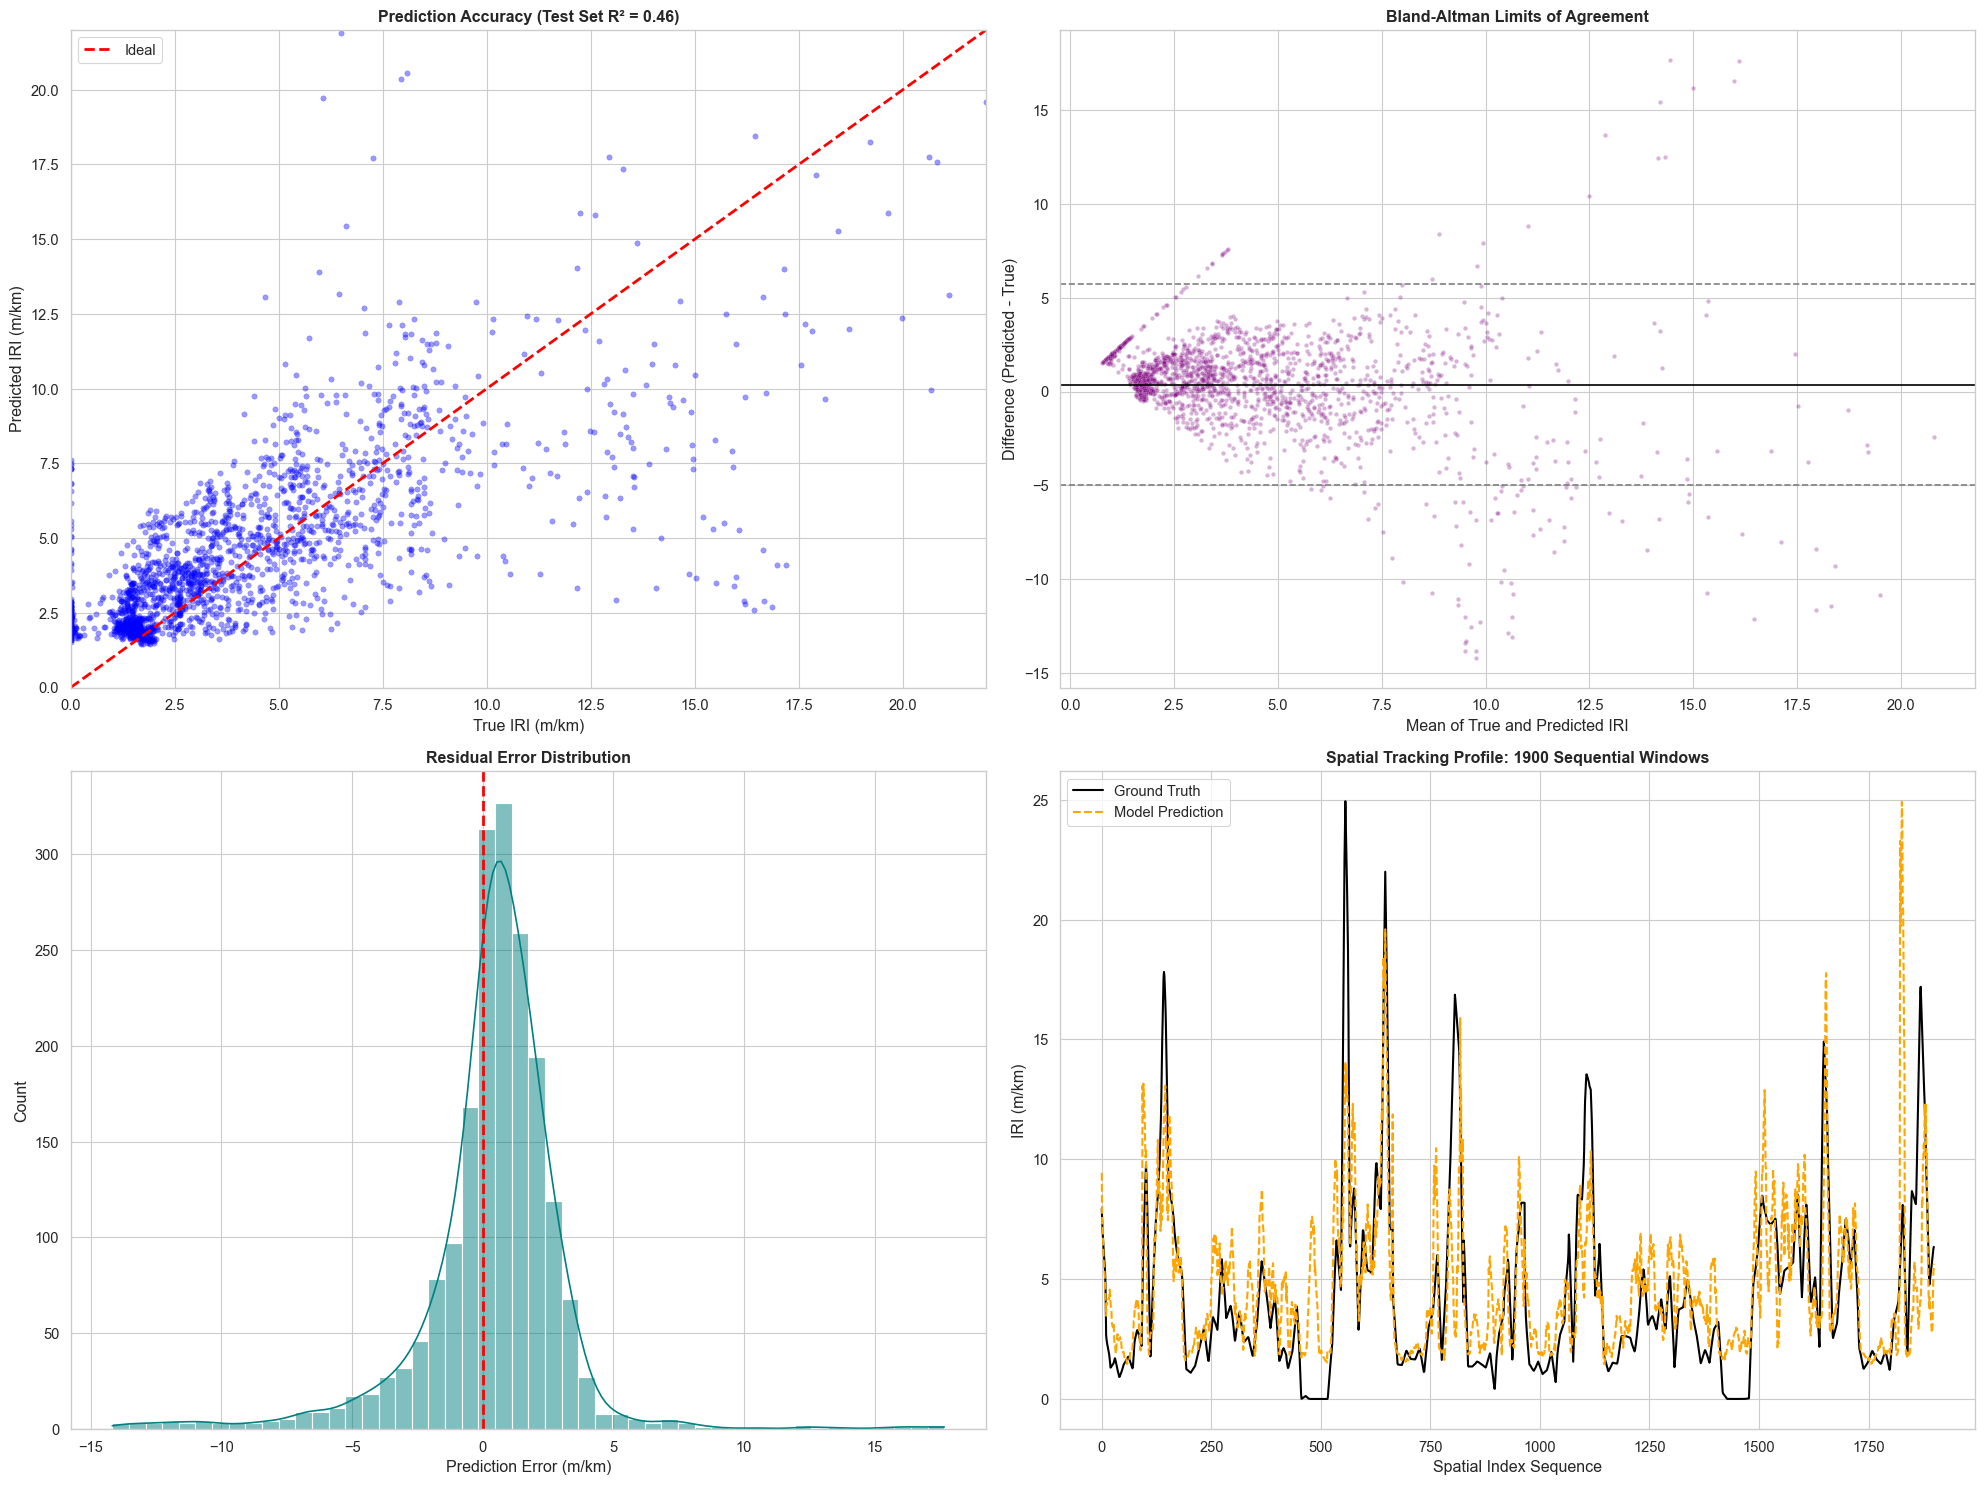

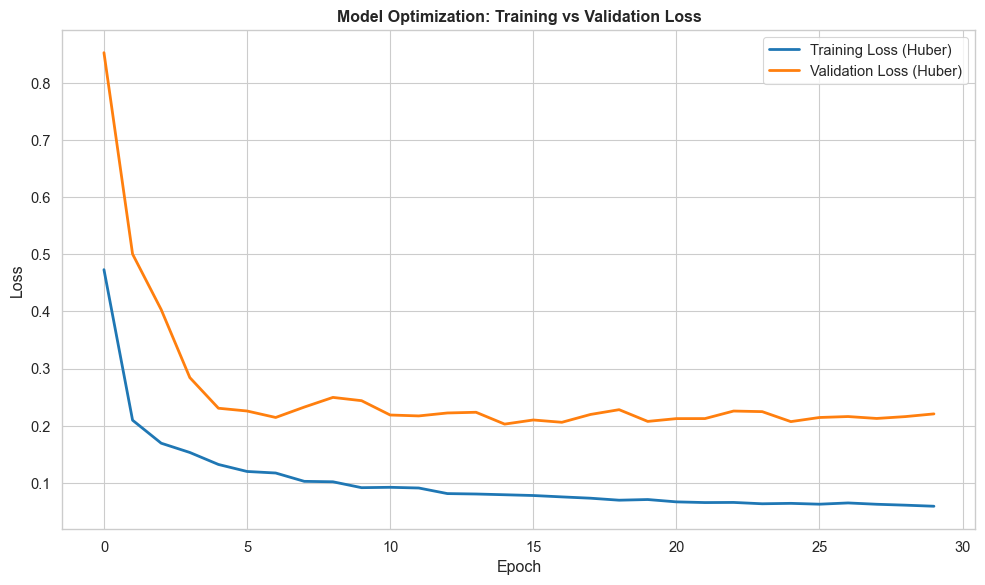

[*] Learning curve exported successfully to D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_v2\output\iri_learning_curve.png



In [6]:
# ==========================================
# Post-Training Validation Metrics
# ==========================================
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

def evaluate_model():
    """Calculates publication metrics, stratified error bounds, and outputs diagnostic plots."""
    data_file = os.path.join(OUTPUT_DIR, "iri_v2_data.npz")
    model_file = os.path.join(OUTPUT_DIR, "best_iri_model.keras")
    
    if not os.path.exists(data_file) or not os.path.exists(model_file):
        print("[!] Target data or neural weights missing. Run training phase first.")
        return
        
    with np.load(data_file) as data:
        X_test_raw, X_test_ctx, y_test = data['x_test_raw'], data['x_test_ctx'], data['y_test']
        
    test_speeds = X_test_ctx[:, 0]
    model = tf.keras.models.load_model(
        model_file, 
        custom_objects={'AsymmetricHuberLoss': AsymmetricHuberLoss}
    )
    y_pred_log = model.predict([X_test_raw, X_test_ctx]).flatten()
    y_pred = np.expm1(y_pred_log)  
    
    # --- THE BOUNCER (NEW CODE) ---
    # Create a True/False list where True means the prediction is sane (< 40)
    valid_mask = y_pred < 40
    removed_count = len(y_pred) - np.sum(valid_mask)
    
    print(f"\n[!] 🚨 ALERT: Yeeted {removed_count} absolute garbage predictions (>= 40) into the void.")

    # Actually filter the data using our mask so the bad rows are gone forever
    y_pred = y_pred[valid_mask]
    y_test = y_test[valid_mask]
    test_speeds = test_speeds[valid_mask]
    # ------------------------------

    # Core Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    pearson_r, _ = pearsonr(y_test, y_pred)
    
    print("\n" + "="*30)
    print("      PUBLICATION METRICS      ")
    print("="*30)
    print(f"Mean Absolute Error:     {mae:.4f} m/km")
    print(f"Root Mean Squared Error: {rmse:.4f} m/km")
    print(f"R-squared (R2 Score):    {r2:.4f}")
    print(f"Pearson Correlation (r): {pearson_r:.4f}")
    
    # Stratified Bins
    print("\n=== Error Distribution by IRI Severity ===")
    bins = [0, 4, 8, 14, 100]
    labels = ["Good (0-4)", "Fair (4-8)", "Poor (8-14)", "Very Poor (>14)"]
    for i in range(len(bins)-1):
        mask = (y_test > bins[i]) & (y_test <= bins[i+1])
        if np.sum(mask) > 0:
            print(f"{labels[i]:<15}: MAE = {mean_absolute_error(y_test[mask], y_pred[mask]):.3f} (n={np.sum(mask)})")
            
    print("\n=== Error Distribution by Velocity Envelope ===")
    speed_bins = [0, 5, 10, 15, 20, 100] 
    speed_labels = ["Very Slow (<18 km/h)", "Slow (18-36)", "Medium (36-54)", "Fast (54-72)", "Highway (>72)"]
    for i in range(len(speed_bins)-1):
        mask = (test_speeds > speed_bins[i]) & (test_speeds <= speed_bins[i+1])
        if np.sum(mask) > 0:
            print(f"{speed_labels[i]:<20}: MAE = {mean_absolute_error(y_test[mask], y_pred[mask]):.3f} | True Avg = {np.mean(y_test[mask]):.2f}")

    # Plot Generation
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Predicted vs True
    ax1 = plt.subplot(2, 2, 1)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='blue', edgecolor=None, s=15, ax=ax1)
    
    # Restrict axes limits to 30 m/km as per practical road roughness bounds
    ax1.set_xlim(0, 22)
    ax1.set_ylim(0, 22)
    
    # Adjust ideal reference line to match new axis limits
    ax1.plot([0, 30], [0, 30], color='red', linestyle='--', linewidth=2, label="Ideal")
    
    ax1.set_title(f"Prediction Accuracy (Test Set R² = {r2:.2f})", fontweight='bold')
    ax1.set_xlabel("True IRI (m/km)")
    ax1.set_ylabel("Predicted IRI (m/km)")
    ax1.legend()

    ax2 = plt.subplot(2, 2, 2)
    diff, md = y_pred - y_test, np.mean(y_pred - y_test)
    sd = np.std(diff)
    sns.scatterplot(x=(y_test + y_pred) / 2, y=diff, alpha=0.3, color='purple', s=10, ax=ax2)
    ax2.axhline(md, color='black', linestyle='-')
    ax2.axhline(md + 1.96*sd, color='gray', linestyle='--')
    ax2.axhline(md - 1.96*sd, color='gray', linestyle='--')
    ax2.set_title("Bland-Altman Limits of Agreement", fontweight='bold')
    ax2.set_xlabel("Mean of True and Predicted IRI")
    ax2.set_ylabel("Difference (Predicted - True)")
    
    ax3 = plt.subplot(2, 2, 3)
    sns.histplot(diff, kde=True, bins=50, color='teal', ax=ax3)
    ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax3.set_title("Residual Error Distribution", fontweight='bold')
    ax3.set_xlabel("Prediction Error (m/km)")
    
    ax4 = plt.subplot(2, 2, 4)
    plot_range = min(2000, len(y_test))
    ax4.plot(y_test[:plot_range], label="Ground Truth", color='black', linewidth=1.5)
    ax4.plot(y_pred[:plot_range], label="Model Prediction", color='orange', linestyle='--', linewidth=1.5)
    ax4.set_title(f"Spatial Tracking Profile: {plot_range} Sequential Windows", fontweight='bold')
    ax4.set_xlabel("Spatial Index Sequence")
    ax4.set_ylabel("IRI (m/km)")
    ax4.legend()
    
    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "iri_model_v2_evaluation.png")
    plt.savefig(plot_path, dpi=300)
    print(f"\n[*] Diagnostic plots exported successfully to {plot_path}")

    # ------------------------------------------
    # Learning Curve (Epoch vs Loss)
    # ------------------------------------------
    history_file = os.path.join(OUTPUT_DIR, 'training_history.csv')
    if os.path.exists(history_file):
        history_df = pd.read_csv(history_file)
        
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=history_df, x=history_df.index, y='loss', label='Training Loss (Huber)', color='#1f77b4', linewidth=2)
        sns.lineplot(data=history_df, x=history_df.index, y='val_loss', label='Validation Loss (Huber)', color='#ff7f0e', linewidth=2)
        
        plt.title("Model Optimization: Training vs Validation Loss", fontweight='bold')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend(frameon=True, facecolor='white')
        plt.tight_layout()
        
        loss_plot_path = os.path.join(OUTPUT_DIR, "iri_learning_curve.png")
        plt.savefig(loss_plot_path, dpi=300)
        plt.show()  
        print(f"[*] Learning curve exported successfully to {loss_plot_path}\n")
    else:
        print("\n[!] training_history.csv not found. Skipping learning curve plot.")

evaluate_model()

## 7. Real-World Inference and Geospatial Visualization

This cell implements the end-to-end inference pipeline for real-world data collected via a mobile sensor application. Unlike the simulation-based training data, real-world recordings use wall-clock timestamps rather than sample indices, and the speed column is denoted `speed` (in m/s) rather than `speed_ms`.

The TFLite interpreter is loaded and its input tensors are identified dynamically by tensor rank: the 3-dimensional tensor corresponds to the raw IMU branch input and the 2-dimensional tensor corresponds to the contextual feature branch input. This approach avoids hardcoding tensor indices, which may vary across TFLite runtimes.

Cumulative odometry is constructed from the timestamp-derived `dt` values. A small monotonic perturbation (`np.arange(len(df)) * 1e-4`) is added to the cumulative distance to guarantee strict monotonicity, which is a prerequisite for `scipy.interpolate.interp1d`. Windows in which the mean speed falls below 0.5 km/h are assigned a nominal IRI of 1.5 m/km, representing a smooth-road baseline, in order to avoid division-by-zero errors in the physics normalization step.

For each valid spatial window, the same preprocessing pipeline applied during training — spatial resampling to `FINAL_STEPS` points, edge-padded interpolation, and physics-based speed normalization of `az` — is applied prior to inference. The raw log-space model output is first inverted via `expm1`, then passed through the calibration lookup table to yield a calibrated IRI estimate. Each prediction is geocoded to the mean GPS coordinates of its window and rendered as a color-coded `folium.CircleMarker` on an interactive map, with severity thresholds: Good (< 4 m/km, green), Fair (4–8 m/km, yellow), Poor (8–14 m/km, orange), and Very Poor (≥ 14 m/km, red). The resulting map is exported as a self-contained HTML file.

In [2]:
import os
import json
import pandas as pd
import numpy as np
import folium
import tensorflow as tf
from scipy.interpolate import interp1d

# ==========================================
# CONFIG
# ==========================================
MODEL_PATH = r"D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_compliant\iri_background_model.tflite"
LUT_PATH = r"D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_compliant\mobile_calibration_lut.json"

CSV_PATH = r"D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_compliant\KMP_mathura.csv"
OUTPUT_MAP = r"D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_compliant\KMP_mathura.html"

# Model 3 Inference Params
WINDOW_SIZE_M = 100.0
STEP_SIZE_M = 10.0 
FINAL_STEPS = 400 
FEATURES = ['ax', 'ay', 'az', 'wx', 'wy', 'wz']

# ==========================================
# EXTRACT CONTEXT FEATURES (Matches Model 3)
# ==========================================
def extract_context_features(raw_data_window, speed_array):
    ax, ay, az, wx, wy, wz = [raw_data_window[:, i] for i in range(6)]
    N = len(az)
    
    speed_mean = np.mean(speed_array)
    speed_std = np.std(speed_array)
    
    rms_az = np.sqrt(np.mean(az**2))
    rms_ay = np.sqrt(np.mean(ay**2))
    var_az = np.var(az)
    crest_factor_az = np.max(np.abs(az)) / (rms_az + 1e-6)
    
    zero_crossings_az = len(np.where(np.diff(np.sign(az)))[0])
    mcr_az = zero_crossings_az / N
    p2p_az = np.max(az) - np.min(az)
    
    rms_wz = np.sqrt(np.mean(wz**2))
    rms_wy = np.sqrt(np.mean(wy**2))
    mean_abs_ax = np.mean(np.abs(ax))
    
    # Pseudo-Spectral features
    fft_vals = np.fft.rfft(az)
    psd = np.abs(fft_vals)**2
    freqs_spatial = np.fft.rfftfreq(N, d=0.25)
    
    if speed_mean > 0:
        freqs_temporal = freqs_spatial * speed_mean
        band_1_4 = np.sum(psd[(freqs_temporal >= 1.0) & (freqs_temporal <= 4.0)])
        band_4_15 = np.sum(psd[(freqs_temporal > 4.0) & (freqs_temporal <= 15.0)])
        total_energy = np.sum(psd) + 1e-6
        
        energy_ratio_1_4 = band_1_4 / total_energy
        energy_ratio_4_15 = band_4_15 / total_energy
    else:
        energy_ratio_1_4, energy_ratio_4_15 = 0.0, 0.0

    return np.array([
        speed_mean, speed_std, rms_az, rms_ay, var_az, crest_factor_az,
        mcr_az, p2p_az, rms_wz, rms_wy, mean_abs_ax, 
        energy_ratio_1_4, energy_ratio_4_15
    ], dtype=np.float32)

# ==========================================
# POST-TRAINING CALIBRATION
# ==========================================
def calibrate_iri(raw_iri, lut_path=LUT_PATH):
    if not os.path.exists(lut_path):
        return raw_iri
    with open(lut_path, 'r') as f:
        lut = json.load(f)
    # Clip out-of-bounds to max/min to prevent explosion
    return float(np.interp(raw_iri, lut['x_raw'], lut['y_calibrated']))

# ==========================================
# SEVERITY COLOR CODING
# ==========================================
def get_color(iri_val):
    if iri_val < 4.0:
        return 'green'
    elif iri_val < 8.0:
        return 'yellow'
    elif iri_val < 14.0:
        return 'orange'
    else:
        return 'red'

# ==========================================
# MAIN PREDICTION PIPELINE
# ==========================================
def predict_and_map():
    print("[+] Loading the TFLite model...")
    interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    # Dynamically match 3D tensor to raw IMU and 2D tensor to context
    raw_input_idx = next(i['index'] for i in input_details if len(i['shape']) == 3)
    ctx_input_idx = next(i['index'] for i in input_details if len(i['shape']) == 2)
    output_idx = output_details[0]['index']

    print("[+] Loading field data from CSV...")
    df = pd.read_csv(CSV_PATH)
    
    # Swap ax and ay
    df[['ax', 'ay']] = df[['ay', 'ax']].to_numpy()

    # Sort out the time and distance
    df['time'] = pd.to_datetime(df['time'], format='mixed')
    df['time_s'] = df['time'].astype(np.int64) / 10**9 # Convert to seconds
    df = df.sort_values('time_s').reset_index(drop=True)
    
    df['dt'] = df['time_s'].diff().fillna(0.1)
    df['dx'] = df['speed'] * df['dt']
    
    #  THE EPSILON HACK 
    df['cumulative_distance'] = df['dx'].cumsum() + (np.arange(len(df)) * 1e-4)
    
    max_dist = df['cumulative_distance'].max()
    
    # Base map centered at the start of your drive
    m = folium.Map(location=[df['latitude'].iloc[0], df['longitude'].iloc[0]], zoom_start=15, tiles='CartoDB positron')
    
    predictions_made = 0

    print("[+] Applying sliding spatial window to field data...")
    for start_dist in np.arange(0, max_dist - WINDOW_SIZE_M, STEP_SIZE_M):
        end_dist = start_dist + WINDOW_SIZE_M
        patch = df[(df['cumulative_distance'] >= start_dist) & (df['cumulative_distance'] < end_dist)]
        
        if len(patch) < 20: 
            continue # Too little data, skip it
            
        avg_speed_ms = patch['speed'].mean()
        avg_speed_kmh = avg_speed_ms * 3.6
        
        # THE DEAD STOP OVERRIDE 
        if avg_speed_kmh < 0.5:
            final_iri = 1.5  # Baseline smooth road
        else:
            # --- DISTANCE DOMAIN RESAMPLING ---
            fixed_spatial_grid = np.linspace(start_dist, end_dist, FINAL_STEPS)
            fixed_patch_features = []
            
            # Interpolate IMU (Safe padding to prevent explosion)
            for feat in FEATURES:
                spatial_fix = interp1d(
                    patch['cumulative_distance'], 
                    patch[feat], 
                    kind='linear', 
                    bounds_error=False, 
                    fill_value=(patch[feat].iloc[0], patch[feat].iloc[-1])
                )
                fixed_patch_features.append(spatial_fix(fixed_spatial_grid))
                
            # Interpolate Speed
            spatial_speed = interp1d(
                patch['cumulative_distance'], 
                patch['speed'], 
                kind='linear', 
                bounds_error=False, 
                fill_value=(patch['speed'].iloc[0], patch['speed'].iloc[-1])
            )(fixed_spatial_grid)
            
            X_raw_filtered = np.column_stack(fixed_patch_features).astype(np.float32)
            
            # --- PHYSICS SPEED NORMALIZATION ---
            # 80 km/h = 22.22 m/s
            az_idx = FEATURES.index('az')
            v_safe = np.maximum(spatial_speed, 5.0) 
            X_raw_filtered[:, az_idx] = X_raw_filtered[:, az_idx] * ((22.22 / v_safe) ** 2)
            
            # --- CONTEXT DATA ---
            X_ctx = extract_context_features(X_raw_filtered, spatial_speed)

            # Batch dimension setup
            X_raw_batch = np.expand_dims(X_raw_filtered, axis=0)
            X_ctx_batch = np.expand_dims(X_ctx, axis=0)

            # --- PREDICT ---
            interpreter.set_tensor(raw_input_idx, X_raw_batch)
            interpreter.set_tensor(ctx_input_idx, X_ctx_batch)
            interpreter.invoke()
            
            # Output is log1p(IRI) -> Convert to Raw IRI -> Apply LUT Calibration
            pred_log = interpreter.get_tensor(output_idx)[0][0]
            pred_iri_raw = np.expm1(pred_log)
            final_iri = calibrate_iri(pred_iri_raw)
        
        # --- PLOT ON MAP ---
        lat = patch['latitude'].mean()
        lon = patch['longitude'].mean()
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            weight=0,
            fill=True,
            fill_color=get_color(final_iri),
            fill_opacity=0.9,
            tooltip=f"IRI: {final_iri:.2f} | Speed: {avg_speed_kmh:.1f}km/h"
        ).add_to(m)
        
        predictions_made += 1

    print(f"[✔] Total Predictions: {predictions_made}")
    m.save(OUTPUT_MAP)
    print(f"[[✔] Geospatial prediction map exported to: {OUTPUT_MAP}")

if __name__ == "__main__":
    predict_and_map()

[+] Loading the TFLite model...
[+] Loading field data from CSV...
[+] Applying sliding spatial window to field data...
[✔] Total Predictions: 11059
[[✔] Geospatial prediction map exported to: D:\Coding\Hackathon\GFG\ARM\ARM\ml_model\iri_compliant\KMP_mathura.html
